# Visualization with Seaborn

Matplotlib is the foundational plotting library in Python and underpins much of the ecosystem. As a low-level, general-purpose tool, it offers fine control but can feel verbose for everyday statistical graphics. Common friction points include historically uneven default styles (now largely addressed), the boilerplate often needed for more sophisticated visualizations, and origins that predate Pandas—so fully label-aware plotting from DataFrames hasn’t always been seamless.

Seaborn builds on Matplotlib with modern style and color defaults, concise high-level plotting functions, and tight Pandas integration. In practice, you can produce attractive, label-aware figures with much less code while still dropping down to Matplotlib for fine control. It also includes quick routines for statistical exploration—distributions, relationships, and categorical patterns—and basic model-fitting and diagnostic plots.

By convention, Seaborn is often imported as sns:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Next we’ll explore a few of Seaborn’s built-in datasets and plot types. Everything we do could be replicated with raw Matplotlib—Seaborn simply wraps those calls under the hood—but its higher-level API makes the workflow far more convenient.

**Histograms, KDE, and Densities**

Often in statistical data visualization, all you want is to plot histograms and joint distributions
of variables. We have seen that this is relatively straightforward in Matplotlib.

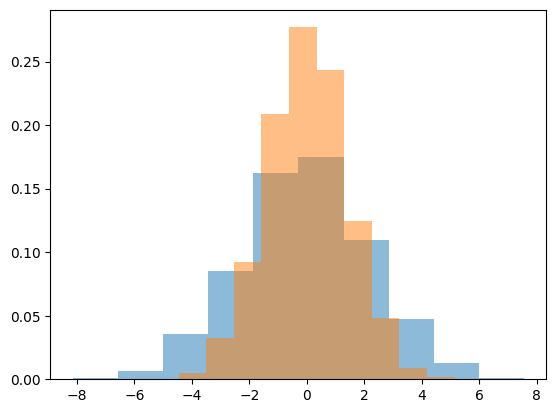

In [13]:
np.random.seed(42)
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5, )

Histograms are useful, but sometimes we want a smoother representation of our data's distribution. We can achieve this using kernel density estimation (KDE), which creates a continuous curve instead of bins. In Seaborn, use sns.kdeplot() to create a KDE plot.

<Axes: ylabel='Density'>

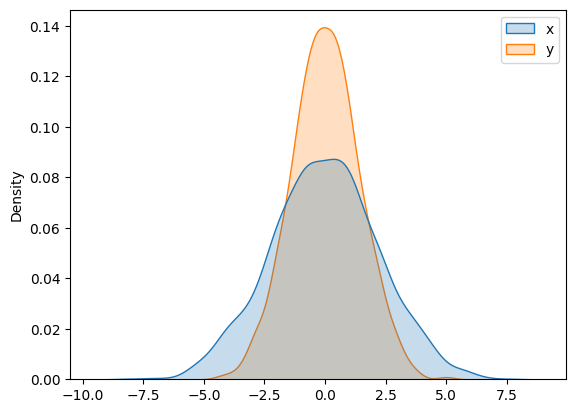

In [15]:
sns.kdeplot(data=data, fill=True)

If we pass x and y columns to kdeplot, we instead get a two-dimensional visualization
of the joint density:

<Axes: xlabel='x', ylabel='y'>

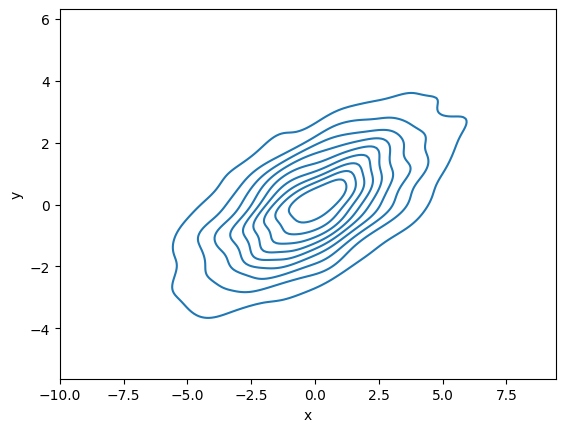

In [16]:
sns.kdeplot(data=data, x='x', y='y')

**Pair Plots**

Pair plots take the concept of joint plots one step further by visualizing relationships between all pairs of variables in a dataset. Instead of creating plots one by one, a pair plot generates an entire grid automatically—perfect for exploring multidimensional data.
We'll use the famous Iris dataset to demonstrate. This dataset contains measurements of petal length, petal width, sepal length, and sepal width for three different iris species:

In [17]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


To visualize all the relationships between variables, simply use sns.pairplot():


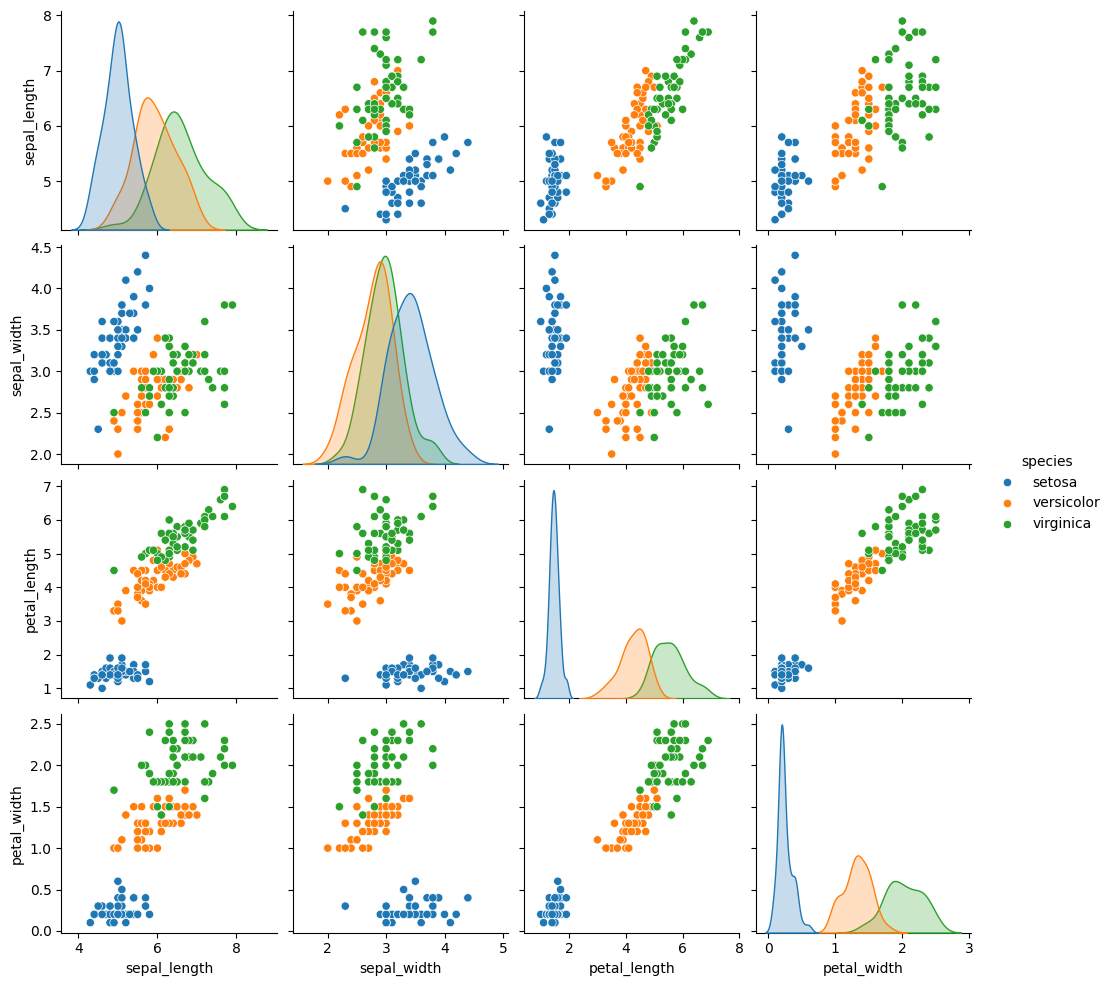

In [18]:
sns.pairplot(iris, hue='species', height=2.5)

**Faceted Histograms**

When comparing multiple groups, side-by-side histograms can reveal patterns that might be hidden in a single plot. Seaborn's FacetGrid allows us to create these comparison plots effortlessly. Let's use a restaurant tipping dataset to see how tip amounts vary across different categories:

In [19]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [20]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

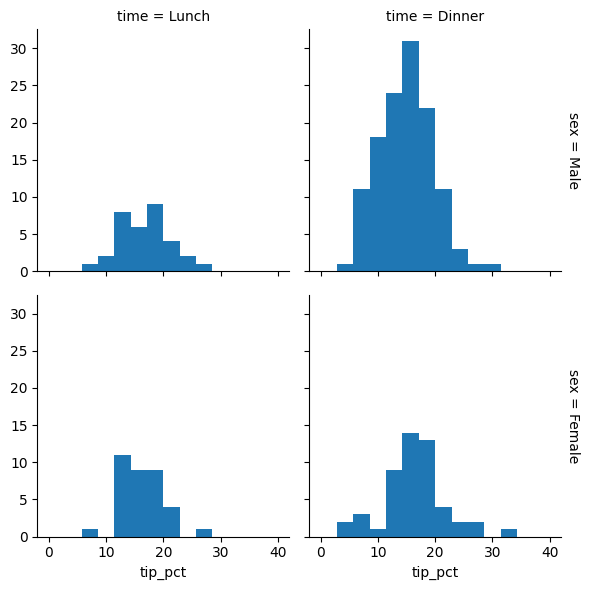

In [21]:
grid = sns.FacetGrid(tips, row="sex", col="time", margin_titles=True)
grid.map(plt.hist, "tip_pct", bins=np.linspace(0, 40, 15))

**Categorical Plots**

  Categorical plots provide another way to visualize these relationships. With categorical plots, you can see how values of one variable (like tip amount) are distributed within categories of another variable (like day of the week), as shown in:

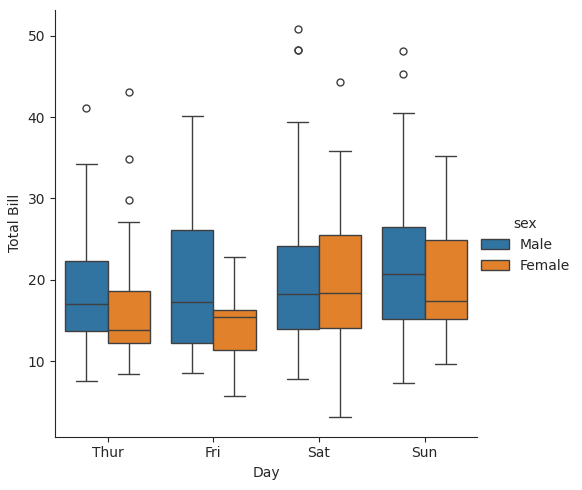

In [25]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x="day", y="total_bill", hue="sex", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill")

**Joint Distributions**

Like the pair plots we saw earlier, sns.jointplot() visualizes the relationship between two variables. However, instead of showing all pairwise relationships, a joint plot focuses on a single pair, displaying both how the variables relate to each other (in the center) and how each variable is distributed individually (along the edges):

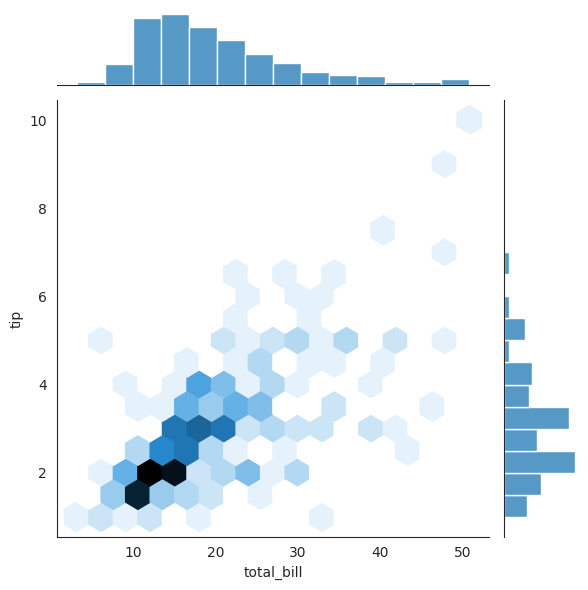

In [27]:
with sns.axes_style('white'):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')

Beyond scatter plots, joint plots can automatically overlay kernel density estimates (to show smooth distributions) and regression lines (to highlight trends):

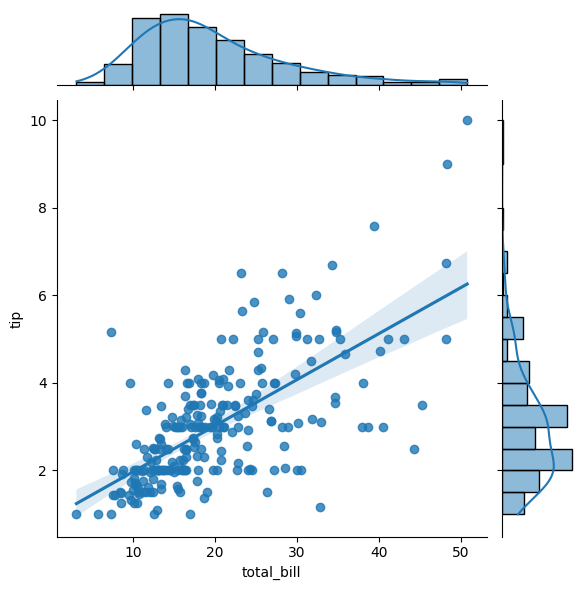

In [28]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg')

In [ ]:
**Bar Plots**

  